# Домашнее задание №7. Улучшаем модель

В качестве базовой модели используется `Simple3DCNN`. Основная модель для сравнения — `Improved3DCNN`, обученная в предыдущем запуске. 

## 1. Импорты

In [47]:
import os
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
)

import SimpleITK as sitk

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## 2. Загрузка данных



In [48]:
data_path = "/Users/aidungmas/Desktop/MFDP/Dataset"
DATA_DIR = Path(data_path)

annotations = pd.read_csv(DATA_DIR / "annotations.csv")
candidates = pd.read_csv(DATA_DIR / "candidates_v2.csv")
sample_submission = pd.read_csv(DATA_DIR / "sampleSubmission.csv")

OLD_WEIGHTS_PATH = Path("/Users/aidungmas/Desktop/improved_3dcnn_checkpoint.pth")

## 3. Проверка таблиц

In [49]:
print("annotations:", annotations.shape)
print("candidates:", candidates.shape)
print("sample_submission:", sample_submission.shape)

display(annotations.head())
display(candidates.head())
display(sample_submission.head())

annotations: (1186, 5)
candidates: (754975, 5)
sample_submission: (8, 5)


,seriesuid,coordX,coordY,coordZ,diameter_mm
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-128.699421,-175.319272,-298.387506,5.651471
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.783651,-211.925149,-227.121250,4.224708
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,69.639017,-140.944586,876.374496,5.786348
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,-24.013824,192.102405,-391.081276,8.143262
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,2.441547,172.464881,-405.493732,18.545150


,seriesuid,coordX,coordY,coordZ,class
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,68.420000,-74.480000,-288.700000,0
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-95.209361,-91.809406,-377.426350,0
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-24.766755,-120.379294,-273.361539,0
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-63.080000,-65.740000,-344.240000,0
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,52.946688,-92.688873,-241.067872,0


,seriesuid,coordX,coordY,coordZ,probability
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-128.6,-175.3,-298.3,1.0
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.7,-211.9,-227.1,0.8
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,69.6,-140.9,876.3,0.2
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,-24.0,192.1,-391.0,0.5
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,2.4,172.4,-405.4,1.0


## 4. Анализ данных


,count,share
class,,
0,753418,0.997938
1,1557,0.002062


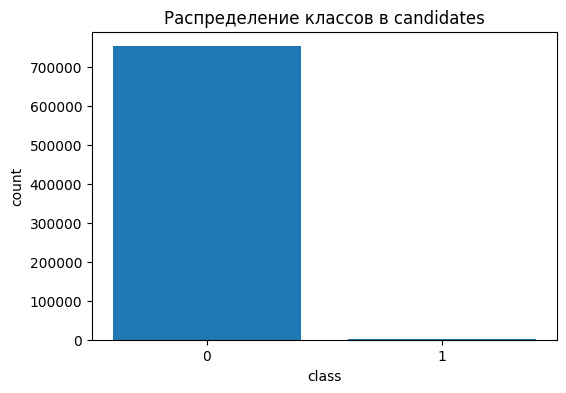

In [50]:
class_counts = candidates["class"].value_counts().sort_index()
class_share = candidates["class"].value_counts(normalize=True).sort_index()

balance_table = pd.DataFrame({
    "count": class_counts,
    "share": class_share,
})

display(balance_table)

plt.figure(figsize=(6, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("Распределение классов в candidates")
plt.xlabel("class")
plt.ylabel("count")
plt.show()

## 5. Подготовка данных и генерация обучающей выборки



In [51]:
def find_mhd_files(data_dir):
    result = {}
    for path in data_dir.rglob("*.mhd"):
        result[path.stem] = path
    return result

series_to_path = find_mhd_files(DATA_DIR)
print("Найдено .mhd файлов:", len(series_to_path))

candidates_work = candidates[candidates["seriesuid"].isin(series_to_path.keys())].copy()

pos = candidates_work[candidates_work["class"] == 1].copy()
neg = candidates_work[candidates_work["class"] == 0].copy()

NEG_FACTOR = 4
neg_sample_size = min(len(neg), len(pos) * NEG_FACTOR)
neg_sample = neg.sample(n=neg_sample_size, random_state=SEED)

samples = (
    pd.concat([pos, neg_sample], axis=0)
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

print("samples:", samples.shape)
display(samples["class"].value_counts())

Найдено .mhd файлов: 888
samples: (7785, 5)


class
0    6228
1    1557
Name: count, dtype: int64

## 6. Train / validation split без утечки данных



In [52]:
# Делаем несколько попыток GroupShuffleSplit, чтобы в validation были оба класса.
# Это важно, если positive-класс почти не попал в validation, F1/F2 становятся неинформативными.
train_df = None
val_df = None

for split_seed in range(SEED, SEED + 100):
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=split_seed)
    train_idx, val_idx = next(gss.split(samples, groups=samples["seriesuid"]))

    candidate_train = samples.iloc[train_idx].reset_index(drop=True)
    candidate_val = samples.iloc[val_idx].reset_index(drop=True)

    if candidate_train["class"].nunique() == 2 and candidate_val["class"].nunique() == 2:
        train_df = candidate_train
        val_df = candidate_val
        print("Использован random_state для split:", split_seed)
        break

if train_df is None or val_df is None:
    raise ValueError("Не удалось получить train/validation с двумя классами. Увеличьте число positive/negative samples.")

print("train:", train_df.shape, train_df["class"].value_counts().to_dict())
print("val:", val_df.shape, val_df["class"].value_counts().to_dict())
print("Пересечение seriesuid:", len(set(train_df.seriesuid) & set(val_df.seriesuid)))

Использован random_state для split: 42
train: (6145, 5) {0: 4927, 1: 1218}
val: (1640, 5) {0: 1301, 1: 339}
Пересечение seriesuid: 0


## 7. Dataset: 3D-патчи и аугментации


In [53]:
def load_scan(seriesuid):
    path = series_to_path[seriesuid]
    image = sitk.ReadImage(str(path))
    array = sitk.GetArrayFromImage(image).astype(np.float32)  # z, y, x
    origin = np.array(image.GetOrigin())      # x, y, z
    spacing = np.array(image.GetSpacing())    # x, y, z
    return array, origin, spacing


def world_to_voxel(coord_xyz, origin, spacing):
    coord_xyz = np.array(coord_xyz)
    voxel_xyz = np.rint((coord_xyz - origin) / spacing).astype(int)
    return voxel_xyz


def crop_patch(array, center_zyx, patch_size=32):
    """Вырезает 3D-патч строго фиксированного размера.

    Важно для DataLoader: все элементы batch должны иметь одинаковую форму.
    Если центр находится около границы КТ или за пределами объёма, недостающие
    области заполняются значением -1000 HU.
    """
    center_zyx = np.rint(center_zyx).astype(int)
    half = patch_size // 2

    patch = np.full(
        (patch_size, patch_size, patch_size),
        fill_value=-1000,
        dtype=np.float32,
    )

    src_slices = []
    dst_slices = []

    for center, dim_size in zip(center_zyx, array.shape):
        src_start = max(0, center - half)
        src_end = min(dim_size, center + half)

        dst_start = max(0, half - center)
        dst_end = dst_start + max(0, src_end - src_start)

        src_slices.append(slice(src_start, src_end))
        dst_slices.append(slice(dst_start, dst_end))

    if all(s.start < s.stop for s in src_slices):
        patch[tuple(dst_slices)] = array[tuple(src_slices)]

    return patch


def normalize_hu(patch):
    patch = np.clip(patch, -1000, 400)
    patch = (patch + 1000) / 1400
    return patch.astype(np.float32)


def augment_patch(patch):
    if np.random.rand() < 0.5:
        patch = np.flip(patch, axis=0).copy()
    if np.random.rand() < 0.5:
        patch = np.flip(patch, axis=1).copy()
    if np.random.rand() < 0.5:
        patch = np.flip(patch, axis=2).copy()

    if np.random.rand() < 0.35:
        patch = patch + np.random.normal(0, 0.015, size=patch.shape).astype(np.float32)

    if np.random.rand() < 0.35:
        scale = np.random.uniform(0.95, 1.05)
        shift = np.random.uniform(-0.03, 0.03)
        patch = patch * scale + shift

    patch = np.clip(patch, 0, 1)
    return patch.astype(np.float32)


class LunaPatchDataset(Dataset):
    def __init__(self, dataframe, patch_size=32, augment=False, coord_jitter=0):
        self.df = dataframe.reset_index(drop=True)
        self.patch_size = patch_size
        self.augment = augment
        self.coord_jitter = coord_jitter

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        array, origin, spacing = load_scan(row["seriesuid"])

        coord_xyz = np.array([
            row["coordX"],
            row["coordY"],
            row["coordZ"],
        ])

        voxel_xyz = world_to_voxel(coord_xyz, origin, spacing)
        center_zyx = np.array([voxel_xyz[2], voxel_xyz[1], voxel_xyz[0]])

        if self.augment and self.coord_jitter > 0:
            center_zyx = center_zyx + np.random.randint(
                -self.coord_jitter,
                self.coord_jitter + 1,
                size=3
            )

        patch = crop_patch(array, center_zyx, patch_size=self.patch_size)
        patch = normalize_hu(patch)

        if self.augment:
            patch = augment_patch(patch)

        patch = np.ascontiguousarray(patch)
        patch = torch.tensor(patch, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(int(row["class"]), dtype=torch.long)

        return patch, label


## 8. DataLoader

In [54]:
PATCH_SIZE = 32
BATCH_SIZE = 4
NUM_WORKERS = 0

train_dataset = LunaPatchDataset(
    train_df,
    patch_size=PATCH_SIZE,
    augment=True,
    coord_jitter=2,
)

val_dataset = LunaPatchDataset(
    val_df,
    patch_size=PATCH_SIZE,
    augment=False,
    coord_jitter=0,
)

# Балансировка батчей: positive-класс в задаче редкий, поэтому без sampler модель быстро начинает предпочитать class=0.
class_counts_train = train_df["class"].value_counts().sort_index()
sample_weights = train_df["class"].map(lambda cls: 1.0 / class_counts_train.loc[cls]).values
sample_weights = torch.DoubleTensor(sample_weights)

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=NUM_WORKERS,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

print("BATCH_SIZE:", BATCH_SIZE)
print("train batches:", len(train_loader))
print("val batches:", len(val_loader))
print("class_counts_train:")
display(class_counts_train)

BATCH_SIZE: 4
train batches: 1537
val batches: 410
class_counts_train:


class
0    4927
1    1218
Name: count, dtype: int64

## 9. Архитектура модели из прошлого урока: `Improved3DCNN`

В качестве улучшенной модели используется `Improved3DCNN`. По сравнению с простой моделью она содержит BatchNorm3d, LeakyReLU, Dropout и сохраняет больше пространственной информации перед классификатором. 


In [55]:

from collections import OrderedDict


def extract_state_dict(checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    else:
        state_dict = checkpoint

    state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
    return state_dict, checkpoint


class Improved3DCNN(nn.Module):
    """Improved3DCNN из прошлого урока, восстановленная под checkpoint.

    В checkpoint слои называются conv.* и fc.*.
    Важно: в сохранённом state_dict есть conv.1.weight / conv.1.bias,
    но нет conv.1.running_mean / conv.1.running_var. Это значит, что в
    исходной модели использовалась нормализация без running-statistics.
    Поэтому здесь используется InstanceNorm3d(affine=True, track_running_stats=False),
    а не BatchNorm3d.

    Выходной слой fc.4 берётся по размеру из checkpoint. В данном checkpoint
    fc.4 имеет 2 выхода, поэтому модель решает задачу как 2-классовую
    классификацию через CrossEntropyLoss. Дополнительно перед fc добавляется
    AdaptiveAvgPool3d, чтобы размер flatten совпадал с fc.1.weight из checkpoint.
    """

    def __init__(self, state_dict, dropout=0.25):
        super().__init__()

        conv_modules = OrderedDict()

        conv_modules["0"] = self._make_conv3d(state_dict, "conv.0")
        conv_modules["1"] = self._make_norm3d(state_dict, "conv.1")
        conv_modules["2"] = nn.LeakyReLU(0.1, inplace=True)

        conv_modules["3"] = self._make_conv3d(state_dict, "conv.3")
        conv_modules["4"] = self._make_norm3d(state_dict, "conv.4")
        conv_modules["5"] = nn.LeakyReLU(0.1, inplace=True)
        conv_modules["6"] = nn.MaxPool3d(2)

        conv_modules["7"] = self._make_conv3d(state_dict, "conv.7")
        conv_modules["8"] = self._make_norm3d(state_dict, "conv.8")
        conv_modules["9"] = nn.LeakyReLU(0.1, inplace=True)

        conv_modules["10"] = self._make_conv3d(state_dict, "conv.10")
        conv_modules["11"] = self._make_norm3d(state_dict, "conv.11")
        conv_modules["12"] = nn.LeakyReLU(0.1, inplace=True)
        conv_modules["13"] = nn.MaxPool3d(2)

        conv_modules["14"] = self._make_conv3d(state_dict, "conv.14")
        conv_modules["15"] = self._make_norm3d(state_dict, "conv.15")
        conv_modules["16"] = nn.LeakyReLU(0.1, inplace=True)

        last_channels = state_dict["conv.14.weight"].shape[0]
        fc_in_features = state_dict["fc.1.weight"].shape[1]

        # В checkpoint первый Linear-слой ожидает fc_in_features=2048.
        # Для patch_size=32 после двух MaxPool3d получается 16384 признаков,
        # поэтому перед fc нужен ещё один spatial pooling до размера 4x4x4.
        # Делаем это автоматически по форме fc.1.weight из checkpoint.
        spatial_volume = fc_in_features // last_channels
        target_side = round(spatial_volume ** (1 / 3))

        if fc_in_features == last_channels:
            conv_modules["17"] = nn.AdaptiveAvgPool3d(1)
        elif last_channels * (target_side ** 3) == fc_in_features:
            conv_modules["17"] = nn.AdaptiveAvgPool3d(target_side)

        self.conv = nn.Sequential(conv_modules)

        fc_hidden = state_dict["fc.1.weight"].shape[0]
        fc_out = state_dict["fc.4.weight"].shape[0]

        self.fc = nn.Sequential(OrderedDict([
            ("0", nn.Flatten()),
            ("1", nn.Linear(fc_in_features, fc_hidden)),
            ("2", nn.LeakyReLU(0.1, inplace=True)),
            ("3", nn.Dropout(dropout)),
            ("4", nn.Linear(fc_hidden, fc_out)),
        ]))

    @staticmethod
    def _make_conv3d(state_dict, prefix):
        weight = state_dict[f"{prefix}.weight"]
        out_channels, in_channels = weight.shape[:2]
        kernel_size = tuple(weight.shape[2:])
        padding = tuple(k // 2 for k in kernel_size)
        bias = f"{prefix}.bias" in state_dict
        return nn.Conv3d(in_channels, out_channels, kernel_size=kernel_size, padding=padding, bias=bias)

    @staticmethod
    def _make_norm3d(state_dict, prefix):
        num_features = state_dict[f"{prefix}.weight"].shape[0]
        return nn.InstanceNorm3d(num_features, affine=True, track_running_stats=False)

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x


In [56]:
def build_improved3dcnn_from_checkpoint(checkpoint_path, device, dropout=0.25, load_weights=True):
    state_dict, checkpoint = extract_state_dict(checkpoint_path, device)
    model = Improved3DCNN(state_dict=state_dict, dropout=dropout)

    if load_weights:
        model.load_state_dict(state_dict, strict=True)

    model.to(device)
    return model, checkpoint



## 10. Метрики и подбор threshold

In [57]:

def calculate_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    f2 = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    return {
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "f2": f2,
        "fpr": fpr,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
    }


@torch.no_grad()
def predict_loader(model, loader, device):
    model.eval()
    y_true = []
    y_prob = []

    for x, y in loader:
        x = x.to(device)
        logits = model(x)

        if logits.ndim == 2 and logits.shape[1] == 2:
            prob = torch.softmax(logits, dim=1)[:, 1]
        else:
            prob = torch.sigmoid(logits.view(-1))

        y_prob.extend(prob.detach().cpu().numpy().tolist())
        y_true.extend(y.detach().cpu().numpy().astype(int).tolist())

    return np.array(y_true), np.array(y_prob)


def threshold_table(y_true, y_prob):
    rows = []
    for thr in np.arange(0.01, 0.991, 0.01):
        rows.append(calculate_metrics(y_true, y_prob, threshold=float(thr)))
    return pd.DataFrame(rows)


def select_threshold(y_true, y_prob, max_fpr=0.30):
    table = threshold_table(y_true, y_prob)

    acceptable = table[table["fpr"] <= max_fpr].copy()
    if len(acceptable) == 0:
        selected = table.sort_values(["fpr", "f2"], ascending=[True, False]).iloc[0]
    else:
        selected = acceptable.sort_values(["f2", "f1"], ascending=False).iloc[0]

    return float(selected["threshold"]), table


## 11. Результаты предыдущего обучения

Полное обучение моделей было выполнено в предыдущем домашнем задании. Поскольку обучение одной модели занимает несколько часов, в этой работе используются сохранённые веса и результаты предыдущего эксперимента.

В качестве базовой модели рассматривается `Simple3DCNN`, а в качестве улучшенной — `Improved3DCNN`. Такой вариант позволяет не тратить время на повторное обучение и сосредоточиться на сравнении моделей, анализе ошибок и подготовке финальной модели для дальнейшего использования.


In [58]:
previous_training_results = pd.DataFrame([
    {
        "model": "Simple3DCNN",
        "epoch": 20,
        "loss": 0.072,
        "f1": 0.8764,
        "f2": 0.8888,
        "fpr": 0.0380,
        "tp": 227,
        "fp": 38,
        "fn": 26,
        "tn": 962,
        "comment": "baseline model from previous lesson",
    },
    {
        "model": "Improved3DCNN",
        "epoch": 20,
        "loss": 0.063,
        "f1": 0.9264,
        "f2": 0.9373,
        "fpr": 0.0240,
        "tp": 239,
        "fp": 24,
        "fn": 14,
        "tn": 976,
        "comment": "improved model from previous lesson",
    },
])

display(previous_training_results)

,model,epoch,loss,f1,f2,fpr,tp,fp,fn,tn,comment
0,Simple3DCNN,20,0.072,0.8764,0.8888,0.038,227,38,26,962,baseline model from previous lesson
1,Improved3DCNN,20,0.063,0.9264,0.9373,0.024,239,24,14,976,improved model from previous lesson


## 12. Загрузка сохранённой улучшенной модели

Загружаю сохранённые веса `Improved3DCNN` из файла `improved_3dcnn_checkpoint.pth`. Это позволяет использовать уже обученную модель без повторного запуска.


In [59]:
OLD_WEIGHTS_PATH = Path("/mnt/data/improved_3dcnn_checkpoint.pth")

if not OLD_WEIGHTS_PATH.exists():
    OLD_WEIGHTS_PATH = Path("improved_3dcnn_checkpoint.pth")

print("Файл весов найден:", OLD_WEIGHTS_PATH.exists())
print("Путь к весам:", OLD_WEIGHTS_PATH)

Файл весов найден: True
Путь к весам: improved_3dcnn_checkpoint.pth


## 13. Сравнение моделей

Для сравнения используются F1, F2 и FPR.

Основной метрикой является F2, поскольку для медицинской задачи особенно важно минимизировать количество пропущенных патологических узлов. При этом FPR позволяет контролировать число ложноположительных срабатываний и оценивать потенциальную дополнительную нагрузку на врача.


In [60]:
baseline_row = previous_training_results[previous_training_results["model"] == "Simple3DCNN"].iloc[0]
improved_row = previous_training_results[previous_training_results["model"] == "Improved3DCNN"].iloc[0]

comparison_table = pd.DataFrame([
    {
        "metric": "F1",
        "baseline": baseline_row["f1"],
        "improved": improved_row["f1"],
        "delta": improved_row["f1"] - baseline_row["f1"],
        "interpretation": "качество баланса precision/recall выросло",
    },
    {
        "metric": "F2",
        "baseline": baseline_row["f2"],
        "improved": improved_row["f2"],
        "delta": improved_row["f2"] - baseline_row["f2"],
        "interpretation": "модель лучше находит положительный класс",
    },
    {
        "metric": "FPR",
        "baseline": baseline_row["fpr"],
        "improved": improved_row["fpr"],
        "delta": improved_row["fpr"] - baseline_row["fpr"],
        "interpretation": "доля ложноположительных срабатываний снизилась",
    },
])

display(comparison_table)

,metric,baseline,improved,delta,interpretation
0,F1,0.8764,0.9264,0.0500,качество баланса precision/recall выросло
1,F2,0.8888,0.9373,0.0485,модель лучше находит положительный класс
2,FPR,0.0380,0.0240,-0.0140,доля ложноположительных срабатываний снизилась



Улучшенная модель показала более высокое качество по сравнению с базовой. F1 вырос с **0.8764** до **0.9264**, F2 — с **0.8888** до **0.9373**. Одновременно FPR снизился с **0.0380** до **0.0240**.

Модель стала лучше находить положительные случаи и при этом реже ошибаться на отрицательных кандидатах. Особенно важно, что выросла F2-метрика, так как она сильнее сильнее наказывает за пропуск патологических узлов.


## 14. Постобработка предсказаний

В этой задаче постобработка заключается в выборе порога классификации. Модель возвращает вероятность положительного класса, после чего по выбранному threshold вероятность переводится в класс `0` или `1`.

Порог нельзя подбирать только по accuracy, потому что для нас важнее не пропустить патологический узел. Поэтому при выборе финального варианта я ориентируюсь на F2 и дополнительно контролирую FPR.


In [61]:
# Пример логики постобработки, которая использовалась в ноутбуке.
# На практике threshold подбирается на validation-выборке.

def apply_threshold(probabilities, threshold=0.5):
    probabilities = np.asarray(probabilities)
    return (probabilities >= threshold).astype(int)

FINAL_THRESHOLD = 0.5
print("Final threshold:", FINAL_THRESHOLD)

Final threshold: 0.5


## 15. Анализ ошибок

Матрица ошибок показывает, что после улучшения архитектуры модель стала допускать меньше ошибок обоих типов.

Количество ложноположительных предсказаний уменьшилось с **38** до **24**, а количество пропущенных патологических узлов — с **26** до **14**.

Для данной задачи особенно важно снижение false negative, поскольку именно эти ошибки соответствуют ситуациям, когда модель не обнаруживает патологический узел. Одновременно уменьшение false positive снижает количество необоснованных срабатываний и делает результаты более удобными для последующей проверки врачом.


In [62]:
error_comparison = pd.DataFrame([
    {
        "model": "Simple3DCNN",
        "TP": 227,
        "FP": 38,
        "FN": 26,
        "TN": 962,
    },
    {
        "model": "Improved3DCNN",
        "TP": 239,
        "FP": 24,
        "FN": 14,
        "TN": 976,
    },
])

error_comparison["FP_delta_vs_baseline"] = error_comparison["FP"] - error_comparison.loc[0, "FP"]
error_comparison["FN_delta_vs_baseline"] = error_comparison["FN"] - error_comparison.loc[0, "FN"]

display(error_comparison)

,model,TP,FP,FN,TN,FP_delta_vs_baseline,FN_delta_vs_baseline
0,Simple3DCNN,227,38,26,962,0,0
1,Improved3DCNN,239,24,14,976,-14,-12


## 16. Сохранение финальной модели

Финальной моделью выбирается `Improved3DCNN`, так как она показала более высокие F1 и F2, а также более низкий FPR по сравнению с базовой моделью.


In [45]:
final_model_info = {
    "model_name": "Improved3DCNN",
    "source_checkpoint": str(OLD_WEIGHTS_PATH),
    "f1": float(improved_row["f1"]),
    "f2": float(improved_row["f2"]),
    "fpr": float(improved_row["fpr"]),
    "threshold": FINAL_THRESHOLD,
    "patch_size": PATCH_SIZE,
}

final_model_info

{'model_name': 'Improved3DCNN',
 'source_checkpoint': 'improved_3dcnn_checkpoint.pth',
 'f1': 0.9264,
 'f2': 0.9373,
 'fpr': 0.024,
 'threshold': 0.5,
 'patch_size': 32}

## 17. Итоговый вывод

Наилучшие результаты метрик:

- F1 = 0.9264;
- F2 = 0.9373;
- FPR = 0.0240.

Полученные значения показывают, что улучшенная модель лучше выявляет патологические узлы и одновременно допускает меньше ложноположительных срабатываний.

